In [2]:
import jax
import jax.numpy as jnp
from flax import linen as nn
from flax.training import train_state
import optax
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
from functools import partial
import scipy.io
from sklearn.model_selection import train_test_split
import time
import pickle
import random
import torch
import itertools
from scipy.interpolate import griddata
import scipy
import os
from scipy.stats import pearsonr
import matplotlib.ticker as mticker

In [3]:
from models_fno import FNO2d
from utils_jax import save_model_params, load_model_params
from utils_jax import dataloader

In [4]:
base_path = "/home/rroy13/scr4-sgoswam4/Rajyasri/PyCahnHilliard/cahn_hilliard_dataset.npz"
# dataset = scipy.io.loadmat(os.path.join(base_path, "AllenCahn2D_32.mat"))
dataset = np.load(base_path,allow_pickle = True)
output = dataset['c']
#inputs = jnp.array(inputs)
output = jnp.array(output[:1250])
del dataset
  # shape: (Ns, Nt, Nx, Ny)

Ns, Nt, Nx, Ny = output.shape
print(f"Ns: {Ns}, Nt: {Nt}, Nx: {Nx}, Ny: {Ny}")

tt = Nt//3

# Create input-output training pairs
init_timestep = 0
end_timestep = tt

# Build pairs without loop
input_data_NN = output[:, init_timestep:end_timestep, :, :]
output_data_NN = output[:, init_timestep+1:end_timestep+1, :, :]

input_data_NN = input_data_NN.reshape(-1, Nx, Ny)
output_data_NN = output_data_NN.reshape(-1, Nx, Ny)

# Mesh
x = jnp.linspace(0, 1, Nx)
y = jnp.linspace(0, 1, Ny)
X, Y = jnp.meshgrid(x, y, indexing="ij")

ntrain = input_data_NN.shape[0]
X_repeated = jnp.broadcast_to(X, (ntrain, Nx, Ny))
Y_repeated = jnp.broadcast_to(Y, (ntrain, Nx, Ny))

# Channels-last
input_data_NN_mod = jnp.concatenate([
    input_data_NN[..., None],
    X_repeated[..., None],
    Y_repeated[..., None]
], axis=-1)

output_data_NN_mod = output_data_NN[..., None]

print(input_data_NN_mod.shape, output_data_NN_mod.shape)

# Free memory
del input_data_NN, output_data_NN, X_repeated, Y_repeated

Ns: 1250, Nt: 201, Nx: 64, Ny: 64
(83750, 64, 64, 3) (83750, 64, 64, 1)


In [5]:
#Separate into train and test datasets
Ntrain = int(0.8*Ns)
perm = jax.random.permutation(jax.random.PRNGKey(0), Ns)

train_idx = perm[:Ntrain]
test_idx = perm[Ntrain:]

train_x = jnp.take(input_data_NN_mod, train_idx, axis=0)
test_x = jnp.take(input_data_NN_mod, test_idx, axis=0)

train_y = jnp.take(output_data_NN_mod, train_idx, axis=0)
test_y = jnp.take(output_data_NN_mod, test_idx, axis=0)

print(f"train_x shape: {train_x.shape}, train_y shape: {train_y.shape}")
print(f"test_x shape: {test_x.shape}, test_y shape: {test_y.shape}")


train_x shape: (1000, 64, 64, 3), train_y shape: (1000, 64, 64, 1)
test_x shape: (250, 64, 64, 3), test_y shape: (250, 64, 64, 1)


In [6]:
train_x.shape

(1000, 64, 64, 3)

In [7]:
modes1 = 32
modes2 = 32

#Create the FNO-2D model object
fno = FNO2d(in_channels = train_x.shape[-1],
            out_channels = train_y.shape[-1],
            modes1 = modes1,
            modes2 = modes2,
            width = 32,
            n_blocks = 4,
            activation = nn.activation.gelu,  
)

model_fn = jax.jit(fno.apply)

In [8]:
#Instantiate the model params
# seed = 42
seed = np.random.choice(np.arange(99999), size=1, replace=True)[0]
print(f"Seed: {seed}")
params = fno.init(jax.random.PRNGKey(seed), train_x[0:1])
total_params = sum(x.size for x in jax.tree_util.tree_leaves(params))
print(f"Total parameters: {total_params:,}")
@jax.jit
def loss_fn(params, x, y):
    # y_pred = model_fn(params, x)
    y_pred = RK4(params,x)
    loss = jnp.mean((y_pred - y) ** 2)
    return loss

@jax.jit
def make_step(params, opt_state, x, y):
    loss, grads = jax.value_and_grad(loss_fn)(params, x, y)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

def create_input_2d(x):
    """
    x: (N, Nx, Ny)
    returns: (N, Nx, Ny, 3)  -> [u, x, y]
    """
    N, Nx, Ny = x.shape

    # Create mesh
    x_lin = jnp.linspace(0, 1, Nx)
    y_lin = jnp.linspace(0, 1, Ny)
    X, Y = jnp.meshgrid(x_lin, y_lin, indexing="ij")  # (Nx, Ny)

    # Repeat for batch
    X_rep = jnp.broadcast_to(X, (N, Nx, Ny))
    Y_rep = jnp.broadcast_to(Y, (N, Nx, Ny))

    # Concatenate along last axis (channels-last)
    x_with_mesh = jnp.concatenate([
        x[..., None],     # (N, Nx, Ny, 1)
        X_rep[..., None], # (N, Nx, Ny, 1)
        Y_rep[..., None]  # (N, Nx, Ny, 1)
    ], axis=-1)

    return x_with_mesh   # (N, Nx, Ny, 3)
# 4th order Runge-Kutta method
@jax.jit
def RK4(params,x):
    dt = 0.01
    # curr_state = x
    # print(x.shape)
    k1 = model_fn(params,x)
    k1 = create_input_2d(k1[...,0])
    # k1 = k1.reshape(k1.shape[0],nx,ny)
    k2 = model_fn(params,x+0.5*dt*k1)
    k2 = create_input_2d(k2[...,0])
    # k2 = k2.reshape(k2.shape[0],nx,ny)
    k3 = model_fn(params,x+0.5*dt*k2)
    k3 = create_input_2d(k3[...,0])
    # k3 = k3.reshape(k3.shape[0],nx,ny)
    k4 = model_fn(params,x+dt*k3)
    k4 = create_input_2d(k4[...,0])
    # k4 = k4_fn(k4.shape[0],nx,ny)
    next_state = x+(dt/6)*(k1+2*k2+2*k3+k4)
    next_state = next_state[...,0]
    next_state = next_state[...,jnp.newaxis]
    print(next_state.shape)
    # next_state = next_state.reshape(next_state.shape[0],nx*ny)
    return next_state

lr = 1e-3
lr_scheduler = optax.schedules.exponential_decay(init_value=lr, transition_steps=2000, decay_rate=0.96)
optimizer = optax.adam(lr_scheduler)
opt_state = optimizer.init(params)

Seed: 57826
Total parameters: 16,781,601


In [9]:
result_dir = "./TI-FNO-params"
filename = f"best_model_params_FNO_TI_2CH.pkl"


In [10]:
from tqdm import tqdm

loss_history = []
val_loss_history = []
# batch_size = 64
batch_size = 256     #Being set only for the computational cost analysis
# shuffle_key = jax.random.PRNGKey(80)
shuffle_key = jax.random.PRNGKey(seed)
epochs = int(5e4)
min_val_loss = jnp.inf


for epoch in (range(epochs)):
    shuffle_key, subkey = jax.random.split(shuffle_key)
    total_loss = 0
    nbatches = 0

    for batch_x, batch_y in tqdm(dataloader(subkey, train_x, train_y, batch_size)):
                                    # desc=f"Epoch {epoch}", leave=False):
        params, opt_state, loss = make_step(params, opt_state, batch_x, batch_y)
        total_loss += loss
        nbatches += 1

    loss = total_loss / nbatches
    val_loss = loss_fn(params, test_x, test_y)

    if val_loss < min_val_loss:
        best_params = params
        min_val_loss = val_loss
        # save_model_params(best_params, result_dir, filename=filename)

    loss_history.append(loss)
    val_loss_history.append(val_loss)

    if epoch % 1000 == 0:
        print(f"Epoch: {epoch}, Train loss: {loss}, Val loss: {val_loss}")


0it [00:00, ?it/s]

(256, 64, 64, 1)


2it [00:09,  4.09s/it]

(232, 64, 64, 1)


4it [00:18,  4.70s/it]


(250, 64, 64, 1)
Epoch: 0, Train loss: 8.09691300673876e-06, Val loss: 8.53259098221315e-06


4it [00:00, 11.27it/s]
4it [00:00, 17.10it/s]
4it [00:00, 17.07it/s]
4it [00:00, 17.09it/s]
4it [00:00, 17.08it/s]
4it [00:00, 17.08it/s]
4it [00:00, 17.08it/s]
4it [00:00, 17.05it/s]
4it [00:00, 16.98it/s]
4it [00:00, 16.93it/s]
4it [00:00, 16.95it/s]
4it [00:00, 16.90it/s]
4it [00:00, 16.94it/s]
4it [00:00, 16.99it/s]
4it [00:00, 17.02it/s]
4it [00:00, 16.93it/s]
4it [00:00, 16.95it/s]
3it [00:00, 13.16it/s]


KeyboardInterrupt: 

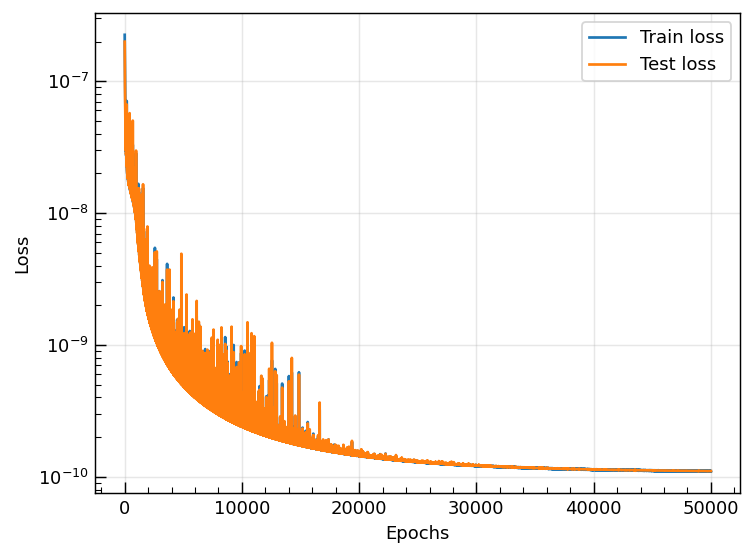

In [9]:
plt.figure(dpi = 130)
plt.semilogy(np.arange(epoch+1), loss_history, label = "Train loss")
plt.semilogy(np.arange(epoch+1), val_loss_history, label = "Test loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.tick_params(which = 'major', axis = 'both', direction = 'in', length = 6)
plt.tick_params(which = 'minor', axis = 'both', direction = 'in', length = 3.5)
plt.minorticks_on()

plt.grid(alpha = 0.3)
plt.legend(loc = 'best')
# plt.savefig(result_dir + f"/loss_plot_{modes1}.jpeg", dpi = 800)
plt.show()

In [12]:
best_params = load_model_params(result_dir, filename = filename)

In [13]:
def create_input_2d(x):
    """
    x: (N, Nx, Ny)
    returns: (N, Nx, Ny, 3)  -> [u, x, y]
    """
    N, Nx, Ny = x.shape

    # Create mesh
    x_lin = jnp.linspace(0, 1, Nx)
    y_lin = jnp.linspace(0, 1, Ny)
    X, Y = jnp.meshgrid(x_lin, y_lin, indexing="ij")  # (Nx, Ny)

    # Repeat for batch
    X_rep = jnp.broadcast_to(X, (N, Nx, Ny))
    Y_rep = jnp.broadcast_to(Y, (N, Nx, Ny))

    # Concatenate along last axis (channels-last)
    x_with_mesh = jnp.concatenate([
        x[..., None],     # (N, Nx, Ny, 1)
        X_rep[..., None], # (N, Nx, Ny, 1)
        Y_rep[..., None]  # (N, Nx, Ny, 1)
    ], axis=-1)

    return x_with_mesh   # (N, Nx, Ny, 3)

def run_inference(initial_u, n_steps):
    u_states = np.zeros_like(output)  # List to store the states over time
    u_states[:,0,:,:] = initial_u
    
    # Initialize the previous state (this could be your u_0 and u_1, etc.)
    u_curr = initial_u  # Set the current state to the initial state
    
    for i in range(1, n_steps):
        
        u_curr_in_FNO = create_input_2d(u_curr) #(Ns, in_channels, Nx)
        # print(i,u_curr_in_FNO.shape)
        u_next_out_FNO = RK4(best_params, u_curr_in_FNO) #(Ns, out_channels, Nx)
        # print(u_next_out_FNO.shape)
        u_next = u_next_out_FNO[..., 0]
        
        # Append the predicted state to the list
        u_states[:,i,:,:] = u_next
        
        # Update previous and current states for the next step
        u_curr = u_next
    
    return u_states



In [14]:
u_curr = output[:, 0, :]

start_time = time.time()
u_pred = run_inference(u_curr, n_steps=Nt)
end_time = time.time()
print(f"Total inferencing time for {u_pred.shape[0]} samples: {end_time-start_time}")

print(f"u_pred: {u_pred.shape}, outputs: {output.shape}")
overall_rel_l2_err = jnp.linalg.norm(u_pred - output)/jnp.linalg.norm(output)
print(f"Overall relative L2 error: {overall_rel_l2_err}")

#Find the autoregressive errors

auto_reg_error = []

for i in range(Nt):
    err = np.linalg.norm(u_pred[:,i,:] - output[:,i,:])/np.linalg.norm(output[:,i,:])
    auto_reg_error.append(err)

(1250, 32, 32, 1)
Total inferencing time for 1250 samples: 9.845414400100708
u_pred: (1250, 101, 32, 32), outputs: (1250, 101, 32, 32)
Overall relative L2 error: 0.004555456340312958
